#### Import packages

In [122]:
using Plots
using LaTeXStrings
include("regression.jl")

polynomial_design_matrix

#### Franke function

Note that the GR backend of Plots.jl does not adjust the draw order of axes and grid when changing the camera setting of 3d surface plots. This can be solved by emulating camera rotation with the following steps:
- Transposing the z matrix
- Reversing the y axis
- Interchanging the x and y axes labels

##### Standard plot

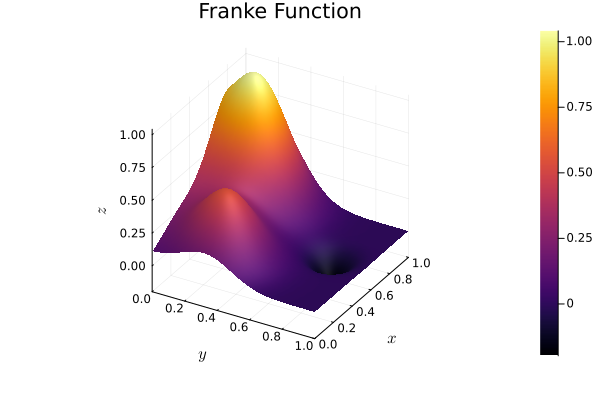

In [23]:
n = 100
x = range(0, 1, length=n)
y = range(0, 1, length=n)
z = franke.(x', y)

surface(x, reverse(y), z',
  xlabel=L"y", ylabel=L"x", zlabel=L"z", 
  title="Franke Function",
  camera=(30,30)
)
#savefig("franke.svg")

##### Noisy plot

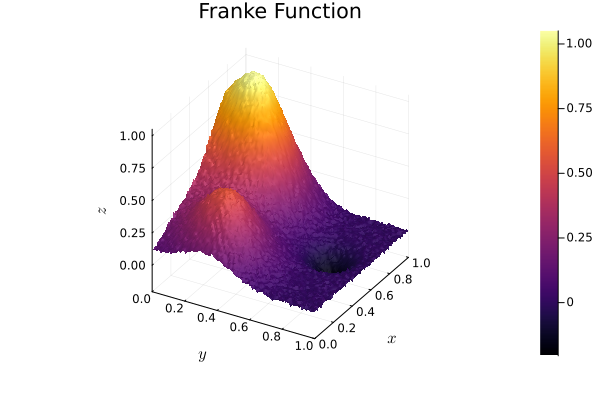

In [25]:
noise_amplitude = 0.01
z_noisy = z .+ randn(size(z)) .* noise_amplitude

surface(x, reverse(y), z_noisy',
  xlabel=L"y", ylabel=L"x", zlabel=L"z", 
  title="Franke Function",
  camera=(30,30)
)

#### Polynomial ordinary least squares regression

In [126]:
X, y = franke_training_data(10, 0.1)
X_poly = polynomial_design_matrix(X, 5)
display(X_poly)

100×21 Matrix{Float64}:
 1.0  -1.55885  -1.55885   2.43   2.43  2.43  …  -9.20483     -9.20483
 1.0  -1.55885  -1.21244   2.43   1.89  1.47     -3.36851     -2.61995
 1.0  -1.55885  -0.866025  2.43   1.35  0.75     -0.876851    -0.487139
 1.0  -1.55885  -0.519615  2.43   0.81  0.27     -0.11364     -0.03788
 1.0  -1.55885  -0.173205  2.43   0.27  0.03     -0.00140296  -0.000155885
 1.0  -1.55885   0.173205  2.43  -0.27  0.03  …  -0.00140296   0.000155885
 1.0  -1.55885   0.519615  2.43  -0.81  0.27     -0.11364      0.03788
 1.0  -1.55885   0.866025  2.43  -1.35  0.75     -0.876851     0.487139
 1.0  -1.55885   1.21244   2.43  -1.89  1.47     -3.36851      2.61995
 1.0  -1.55885   1.55885   2.43  -2.43  2.43     -9.20483      9.20483
 ⋮                                      ⋮     ⋱                ⋮
 1.0   1.55885  -1.21244   2.43  -1.89  1.47      3.36851     -2.61995
 1.0   1.55885  -0.866025  2.43  -1.35  0.75      0.876851    -0.487139
 1.0   1.55885  -0.519615  2.43  -0.81  0.27    

In [29]:
sample_size = 100
train_ratio = 0.8

Random.seed!(0)
x_1 = rand(sample_size)
x_2 = rand(sample_size)
y = franke.(x_1', x_2)

x = hcat(x_1, x_2)
x_scaled = scale_data(x)

x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, train_ratio)

degrees = 10
mse = Vector{Float64}(undef, degrees)
R_squared = Vector{Float64}(undef, degrees)
for p in 1:degrees
  X_train = polynomial_design_matrix(x_train, p)
  β = ordinary_least_squares(X_train, y_train)
  X_test = polynomial_design_matrix(x_test, p)
  y_pred = X_test * β
  mse[p] = mean((y_test - y_pred).^2)
  R_squared[p] = r_squared(y_test, y_pred)
end

layout = @layout [a ; b]

p1 = plot(
  1:degrees, mse, 
  marker=:circle, 
  label="", 
  title="Mean Squared Error", 
  xlabel="p", 
  ylabel="MSE")
p2 = plot(
  1:degrees, R_squared, 
  marker=:circle, 
  label="", 
  title=L"R^2", 
  xlabel="p", 
  ylabel=L"R^2")
plot(p1, p2, layout=layout)

MethodError: MethodError: no method matching train_test_split(::Matrix{Float64}, ::Matrix{Float64}, ::Float64)

Closest candidates are:
  train_test_split(::Matrix{Float64}, !Matched::Vector{Float64}, ::Float64)
   @ Main c:\Users\danfy\Documents\Projects\fys-stk4155\project_1\code\regression.jl:34
  train_test_split(::Matrix{Float64}, !Matched::Vector{Float64})
   @ Main c:\Users\danfy\Documents\Projects\fys-stk4155\project_1\code\regression.jl:34
